# 03 — Model Training

Sequential training of Ticket Category, Priority, and Sentiment classifiers.

**Important:** This notebook does not guarantee 90%+ accuracy. Accuracy depends on the real labels and separability of the dataset. Synthetic augmentation is used only on the training split to improve training balance; the test split remains untouched.


In [1]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
MODEL_DIR = PROJECT_ROOT / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

data = pd.read_csv(DATA_DIR / 'support_tickets_processed.csv')
TEXT_COLUMN = 'ticket_text_clean' if 'ticket_text_clean' in data.columns else 'ticket_text'
print('Dataset:', data.shape)
print('Text column:', TEXT_COLUMN)


c:\Users\shikh\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_param_validation.py:11: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.5.2)
  from scipy.sparse import csr_matrix, issparse


Dataset: (10000, 19)
Text column: ticket_text_clean


## 1. Ticket Category Classifier

In [3]:
X = data[TEXT_COLUMN].fillna('')
y = data['ticket_category']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
vectorizer = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.95, sublinear_tf=True, max_features=100000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
model = LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42)
model.fit(X_train_tfidf, y_train)
pred = model.predict(X_test_tfidf)
print('Accuracy:', accuracy_score(y_test,pred))
print(classification_report(y_test,pred))
joblib.dump(model, MODEL_DIR/'ticket_category_model.pkl')
joblib.dump(vectorizer, MODEL_DIR/'ticket_category_tfidf.pkl')


Accuracy: 1.0
                          precision    recall  f1-score   support

         Account & Login       1.00      1.00      1.00       206
     App & Website Issue       1.00      1.00      1.00       143
          Delivery Issue       1.00      1.00      1.00       390
           Payment Issue       1.00      1.00      1.00       295
           Product Issue       1.00      1.00      1.00       390
         Refund & Return       1.00      1.00      1.00       410
Seller & Product Listing       1.00      1.00      1.00       166

                accuracy                           1.00      2000
               macro avg       1.00      1.00      1.00      2000
            weighted avg       1.00      1.00      1.00      2000



['c:\\Users\\shikh\\OneDrive\\Desktop\\Multi-Agent-Customer-Support-Intelligence-Platform\\models\\ticket_category_tfidf.pkl']

## 2. Priority Classifier

In [4]:
X = data[TEXT_COLUMN].fillna('')
y = data['priority']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
vectorizer = TfidfVectorizer(ngram_range=(1,3), min_df=2, max_df=0.95, sublinear_tf=True, max_features=100000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
model = LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42)
model.fit(X_train_tfidf, y_train)
pred = model.predict(X_test_tfidf)
print('Accuracy:', accuracy_score(y_test,pred))
print(classification_report(y_test,pred))
joblib.dump(model, MODEL_DIR/'priority_model.pkl')
joblib.dump(vectorizer, MODEL_DIR/'priority_tfidf.pkl')


Accuracy: 0.9135
              precision    recall  f1-score   support

        High       0.92      0.94      0.93       924
         Low       0.92      0.78      0.85       345
      Medium       0.90      0.95      0.92       731

    accuracy                           0.91      2000
   macro avg       0.92      0.89      0.90      2000
weighted avg       0.91      0.91      0.91      2000



['c:\\Users\\shikh\\OneDrive\\Desktop\\Multi-Agent-Customer-Support-Intelligence-Platform\\models\\priority_tfidf.pkl']

## 3. Sentiment Classifier — augmented training only

In [5]:
sent_df = data[[TEXT_COLUMN, 'sentiment']].copy().rename(columns={TEXT_COLUMN:'text'})
sent_df['text'] = sent_df['text'].fillna('')
X_train_sent, X_test_sent, y_train_sent, y_test_sent = train_test_split(
    sent_df['text'], sent_df['sentiment'], test_size=0.20, random_state=42, stratify=sent_df['sentiment']
)
train_sent = pd.DataFrame({'text':X_train_sent.values, 'sentiment':y_train_sent.values})
test_sent = pd.DataFrame({'text':X_test_sent.values, 'sentiment':y_test_sent.values})
print('Original training distribution:\n', train_sent['sentiment'].value_counts())
print('\nUntouched test distribution:\n', test_sent['sentiment'].value_counts())


Original training distribution:
 sentiment
Negative             2462
Neutral              2186
Slightly Negative    1440
Very Negative        1234
Positive              678
Name: count, dtype: int64

Untouched test distribution:
 sentiment
Negative             615
Neutral              546
Slightly Negative    360
Very Negative        309
Positive             170
Name: count, dtype: int64


### 3.1 Conservative synthetic augmentation
Synthetic examples are generated from real training-ticket context. The test set is never augmented.

In [6]:
import random
random.seed(42)
np.random.seed(42)

phrases = {
 'Very Negative':['This is absolutely unacceptable.','I am extremely frustrated with this issue.','This has been a terrible experience.','I am extremely disappointed with the service.'],
 'Negative':['I am disappointed with the service.','This has been a frustrating experience.','I am unhappy with how this issue was handled.'],
 'Slightly Negative':['I am a little disappointed with the service.','This was not quite what I expected.','The service could have been better.'],
 'Neutral':['I would like an update about this request.','Can you provide more information about this?','I would like to know the current status.'],
 'Positive':['I am very happy with the service.','Thank you for resolving this quickly.','I really appreciate your support.']
}

target_sizes = train_sent['sentiment'].value_counts().to_dict()
target_max = max(target_sizes.values())
synthetic_rows=[]

for label, current in target_sizes.items():
    # Moderate augmentation; do not manufacture huge quantities.
    desired = min(target_max, current + int(0.50 * (target_max-current)))
    needed = max(0, desired-current)
    source = train_sent[train_sent['sentiment']==label]
    for i in range(needed):
        base = source.sample(1, random_state=1000+i).iloc[0]['text']
        synthetic_rows.append({'text': f"{base} {random.choice(phrases[label])}", 'sentiment':label, 'synthetic':True})

synthetic_df = pd.DataFrame(synthetic_rows)
train_sent['synthetic']=False
aug_train = pd.concat([train_sent, synthetic_df], ignore_index=True)
print('Synthetic rows:', len(synthetic_df))
print('\nAugmented distribution:\n', aug_train['sentiment'].value_counts())


Synthetic rows: 2155

Augmented distribution:
 sentiment
Negative             2462
Neutral              2324
Slightly Negative    1951
Very Negative        1848
Positive             1570
Name: count, dtype: int64


### 3.2 Word + character TF-IDF

In [7]:
from scipy.sparse import hstack
word_vec = TfidfVectorizer(analyzer='word', ngram_range=(1,3), min_df=2, max_df=0.98, sublinear_tf=True, max_features=150000)
char_vec = TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), min_df=2, sublinear_tf=True, max_features=100000)
X_train_word = word_vec.fit_transform(aug_train['text'])
X_test_word = word_vec.transform(test_sent['text'])
X_train_char = char_vec.fit_transform(aug_train['text'])
X_test_char = char_vec.transform(test_sent['text'])
X_train_sent_tfidf = hstack([X_train_word, X_train_char])
X_test_sent_tfidf = hstack([X_test_word, X_test_char])
print('Train features:', X_train_sent_tfidf.shape)
print('Test features :', X_test_sent_tfidf.shape)


Train features: (10155, 48361)
Test features : (2000, 48361)


### 3.3 LinearSVC sentiment model

In [8]:
sentiment_model = LinearSVC(C=1.5, class_weight='balanced', max_iter=20000, random_state=42)
sentiment_model.fit(X_train_sent_tfidf, aug_train['sentiment'])
sentiment_pred = sentiment_model.predict(X_test_sent_tfidf)
print('Sentiment model trained successfully.')


Sentiment model trained successfully.


In [9]:
sentiment_accuracy = accuracy_score(test_sent['sentiment'], sentiment_pred)
sentiment_precision = precision_score(test_sent['sentiment'], sentiment_pred, average='weighted')
sentiment_recall = recall_score(test_sent['sentiment'], sentiment_pred, average='weighted')
sentiment_f1 = f1_score(test_sent['sentiment'], sentiment_pred, average='weighted')
sentiment_macro_f1 = f1_score(test_sent['sentiment'], sentiment_pred, average='macro')
print('Accuracy :', round(sentiment_accuracy,4))
print('Precision:', round(sentiment_precision,4))
print('Recall   :', round(sentiment_recall,4))
print('Weighted F1:', round(sentiment_f1,4))
print('Macro F1:', round(sentiment_macro_f1,4))
print('\nClassification Report:\n', classification_report(test_sent['sentiment'], sentiment_pred))


Accuracy : 0.5135
Precision: 0.4849
Recall   : 0.5135
Weighted F1: 0.4804
Macro F1: 0.4189

Classification Report:
                    precision    recall  f1-score   support

         Negative       0.61      0.84      0.71       615
          Neutral       0.46      0.55      0.50       546
         Positive       0.47      0.22      0.30       170
Slightly Negative       0.42      0.38      0.40       360
    Very Negative       0.35      0.12      0.18       309

         accuracy                           0.51      2000
        macro avg       0.46      0.42      0.42      2000
     weighted avg       0.48      0.51      0.48      2000



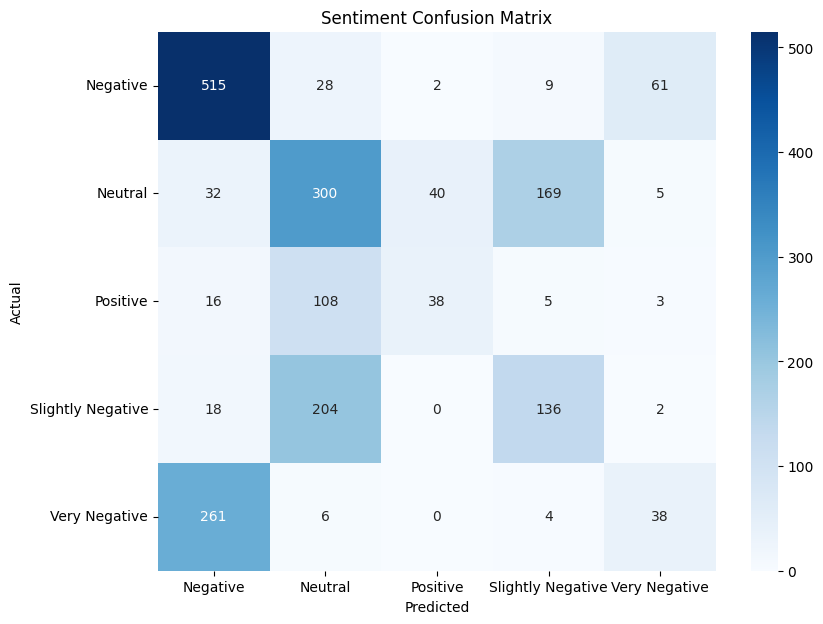

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(test_sent['sentiment'], sentiment_pred, labels=sentiment_model.classes_)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=sentiment_model.classes_, yticklabels=sentiment_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Sentiment Confusion Matrix')
plt.show()


In [11]:
joblib.dump(sentiment_model, MODEL_DIR/'sentiment_model.pkl')
joblib.dump(word_vec, MODEL_DIR/'sentiment_word_tfidf.pkl')
joblib.dump(char_vec, MODEL_DIR/'sentiment_char_tfidf.pkl')
aug_train.to_csv(DATA_DIR/'sentiment_augmented_train.csv', index=False)
synthetic_df.to_csv(DATA_DIR/'sentiment_synthetic_data.csv', index=False)
print('Sentiment artifacts and augmented data saved.')


Sentiment artifacts and augmented data saved.


In [12]:
print('Training completed.')
print('Ticket Category, Priority, and Sentiment models saved in:', MODEL_DIR)


Training completed.
Ticket Category, Priority, and Sentiment models saved in: c:\Users\shikh\OneDrive\Desktop\Multi-Agent-Customer-Support-Intelligence-Platform\models
